# Optimizing Supply Chain Logistics: A Data-Driven Approach to Inventory Management and Demand Forecasting

## Capstone Project — IDRA Data Science & AI Training Program

This notebook contains the complete reproducible analysis for the supply-chain capstone. It follows the report structure: data understanding, cleaning, preprocessing, EDA, statistical analysis, feature engineering, time-aware model development, evaluation, findings and supporting outputs.

**Target:** `Units_Sold` (daily demand proxy)

**Important modelling assumption:** `Demand_Forecast` is treated as a planning-time forecast already available before actual sales are observed. It is therefore used as an input signal and also evaluated as a standalone baseline. If that column is generated using information unavailable before the prediction date in the real system, it should be removed to avoid leakage.

## 1. Imports and Data Loading

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", 100)

DATA_PATH = "P_3_supply_chain_dataset1.csv"
if not os.path.exists(DATA_PATH):
    candidates = [p for p in os.listdir(".") if p.lower().endswith(".csv")]
    if not candidates:
        raise FileNotFoundError("Place P_3_supply_chain_dataset1.csv in the notebook working directory.")
    DATA_PATH = candidates[0]

df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
display(df.head())
display(df.dtypes)

Dataset shape: (91250, 15)


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,0,8.52
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,0,18.63
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,0,39.62
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,0,19.43
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,0,18.70


Date                        object
SKU_ID                      object
Warehouse_ID                object
Supplier_ID                 object
Region                      object
Units_Sold                   int64
Inventory_Level              int64
Supplier_Lead_Time_Days      int64
Reorder_Point                int64
Order_Quantity               int64
Unit_Cost                  float64
Unit_Price                 float64
Promotion_Flag               int64
Stockout_Flag                int64
Demand_Forecast            float64
dtype: object

## 2. Dataset Understanding

In [2]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("Unique SKUs:", df["SKU_ID"].nunique())
print("Unique warehouses:", df["Warehouse_ID"].nunique())
print("Unique suppliers:", df["Supplier_ID"].nunique())
print("Unique regions:", df["Region"].nunique())

profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "unique": df.nunique(),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(3)
})
display(profile)

display(df.describe(include="all").T)

Rows: 91250
Columns: 15
Date range: 2024-01-01 to 2024-12-30
Unique SKUs: 50
Unique warehouses: 5
Unique suppliers: 10
Unique regions: 4


,dtype,unique,missing,missing_pct
Date,object,365,0,0.0
SKU_ID,object,50,0,0.0
Warehouse_ID,object,5,0,0.0
Supplier_ID,object,10,0,0.0
Region,object,4,0,0.0
Units_Sold,int64,58,0,0.0
Inventory_Level,int64,781,0,0.0
Supplier_Lead_Time_Days,int64,13,0,0.0
Reorder_Point,int64,142,0,0.0
Order_Quantity,int64,301,0,0.0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,91250,365,2024-01-01,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SKU_ID,91250,50,SKU_1,1825,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Warehouse_ID,91250,5,WH_1,18250,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Supplier_ID,91250,10,SUP_7,12410,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,91250,4,North,22974,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Units_Sold,91250.0,NaN,NaN,NaN,20.054564,9.068602,0.0,13.0,20.0,27.0,59.0
Inventory_Level,91250.0,NaN,NaN,NaN,471.522312,133.488002,168.0,370.0,461.0,564.0,990.0
Supplier_Lead_Time_Days,91250.0,NaN,NaN,NaN,7.984,3.907929,2.0,4.0,8.0,11.0,14.0
Reorder_Point,91250.0,NaN,NaN,NaN,300.068,54.879945,201.0,252.0,300.0,346.0,398.0
Order_Quantity,91250.0,NaN,NaN,NaN,19.272493,82.340831,0.0,0.0,0.0,0.0,499.0


## 3. Data Cleaning

In [3]:
raw_shape = df.shape
raw_duplicates = int(df.duplicated().sum())

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
invalid_date_count = int(df["Date"].isna().sum())

numeric_cols = [
    "Units_Sold", "Inventory_Level", "Supplier_Lead_Time_Days",
    "Reorder_Point", "Order_Quantity", "Unit_Cost", "Unit_Price",
    "Promotion_Flag", "Stockout_Flag", "Demand_Forecast"
]

missing_before = df.isna().sum()
print("Duplicate rows:", raw_duplicates)
print("Invalid dates after conversion:", invalid_date_count)
display(missing_before[missing_before > 0])

for col in ["SKU_ID", "Warehouse_ID", "Supplier_ID", "Region"]:
    print(col, sorted(df[col].dropna().unique())[:10], "...", df[col].nunique(), "unique values")

outlier_summary = []
for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = int(((df[col] < lo) | (df[col] > hi)).sum())
    outlier_summary.append([col, q1, q3, iqr, lo, hi, count])

outlier_summary = pd.DataFrame(
    outlier_summary,
    columns=["Variable","Q1","Q3","IQR","Lower Fence","Upper Fence","IQR Flag Count"]
)
display(outlier_summary)

print("Cleaned shape:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())
print("Remaining missing cells:", int(df.isna().sum().sum()))

Duplicate rows: 0
Invalid dates after conversion: 0


Series([], dtype: int64)

SKU_ID ['SKU_1', 'SKU_10', 'SKU_11', 'SKU_12', 'SKU_13', 'SKU_14', 'SKU_15', 'SKU_16', 'SKU_17', 'SKU_18'] ... 50 unique values


Warehouse_ID ['WH_1', 'WH_2', 'WH_3', 'WH_4', 'WH_5'] ... 5 unique values
Supplier_ID ['SUP_1', 'SUP_10', 'SUP_2', 'SUP_3', 'SUP_4', 'SUP_5', 'SUP_6', 'SUP_7', 'SUP_8', 'SUP_9'] ... 10 unique values


Region ['East', 'North', 'South', 'West'] ... 4 unique values


,Variable,Q1,Q3,IQR,Lower Fence,Upper Fence,IQR Flag Count
0,Units_Sold,13.00,27.00,14.00,-8.000,48.000,110
1,Inventory_Level,370.00,564.00,194.00,79.000,855.000,199
2,Supplier_Lead_Time_Days,4.00,11.00,7.00,-6.500,21.500,0
3,Reorder_Point,252.00,346.00,94.00,111.000,487.000,0
4,Order_Quantity,0.00,0.00,0.00,0.000,0.000,5027
5,Unit_Cost,8.18,16.32,8.14,-4.030,28.530,0
6,Unit_Price,12.00,23.39,11.39,-5.085,40.475,0
7,Promotion_Flag,0.00,0.00,0.00,0.000,0.000,9270
8,Stockout_Flag,0.00,0.00,0.00,0.000,0.000,0
9,Demand_Forecast,12.95,26.93,13.98,-8.020,47.900,185


Cleaned shape: (91250, 15)
Remaining duplicates: 0
Remaining missing cells: 0


## 4. Feature Engineering and Preprocessing

The target is `Units_Sold`. `Stockout_Flag` is excluded because it is constant at zero in the supplied data and could represent an outcome rather than a pre-demand predictor. The existing `Demand_Forecast` is retained under the explicit assumption that it is available before actual sales and represents an existing planning forecast that the ML model can calibrate.

In [4]:
df = df.sort_values(["SKU_ID", "Warehouse_ID", "Date"]).reset_index(drop=True)

group = df.groupby(["SKU_ID", "Warehouse_ID"], sort=False)["Units_Sold"]
df["Lag_1"] = group.shift(1)
df["Lag_7"] = group.shift(7)

df["Rolling_Mean_7"] = df.groupby(["SKU_ID", "Warehouse_ID"])["Units_Sold"].transform(
    lambda s: s.shift(1).rolling(7).mean()
)
df["Rolling_Mean_30"] = df.groupby(["SKU_ID", "Warehouse_ID"])["Units_Sold"].transform(
    lambda s: s.shift(1).rolling(30).mean()
)
df["Rolling_Std_7"] = df.groupby(["SKU_ID", "Warehouse_ID"])["Units_Sold"].transform(
    lambda s: s.shift(1).rolling(7).std()
)

df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Month"] = df["Date"].dt.month
df["DayOfMonth"] = df["Date"].dt.day
df["DayOfYear"] = df["Date"].dt.dayofyear
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

df["Month_Sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_Cos"] = np.cos(2 * np.pi * df["Month"] / 12)
df["DayOfYear_Sin"] = np.sin(2 * np.pi * df["DayOfYear"] / 365)
df["DayOfYear_Cos"] = np.cos(2 * np.pi * df["DayOfYear"] / 365)

df["Price_Cost_Ratio"] = df["Unit_Price"] / df["Unit_Cost"]
df["Below_Reorder_Point"] = (df["Inventory_Level"] < df["Reorder_Point"]).astype(int)

model_df = df.dropna(
    subset=["Lag_1", "Lag_7", "Rolling_Mean_7", "Rolling_Mean_30", "Rolling_Std_7"]
).copy()

target = "Units_Sold"
features = [
    "Inventory_Level", "Supplier_Lead_Time_Days", "Reorder_Point", "Order_Quantity",
    "Unit_Cost", "Unit_Price", "Promotion_Flag",
    "Lag_1", "Lag_7", "Rolling_Mean_7", "Rolling_Mean_30", "Rolling_Std_7",
    "DayOfWeek", "Month", "DayOfMonth", "IsWeekend", "Price_Cost_Ratio",
    "Demand_Forecast", "DayOfYear", "Month_Sin", "Month_Cos",
    "DayOfYear_Sin", "DayOfYear_Cos"
]

unique_dates = np.sort(model_df["Date"].unique())
cutoff = unique_dates[int(len(unique_dates) * 0.80) - 1]

train = model_df[model_df["Date"] <= cutoff].copy()
test = model_df[model_df["Date"] > cutoff].copy()

print("Rows after history features:", len(model_df))
print("Training period:", train["Date"].min().date(), "to", train["Date"].max().date())
print("Testing period :", test["Date"].min().date(), "to", test["Date"].max().date())
print("Train rows:", len(train), "Test rows:", len(test))

Rows after history features: 83750
Training period: 2024-01-31 to 2024-10-24
Testing period : 2024-10-25 to 2024-12-30
Train rows: 67000 Test rows: 16750


## 5. Exploratory Data Analysis

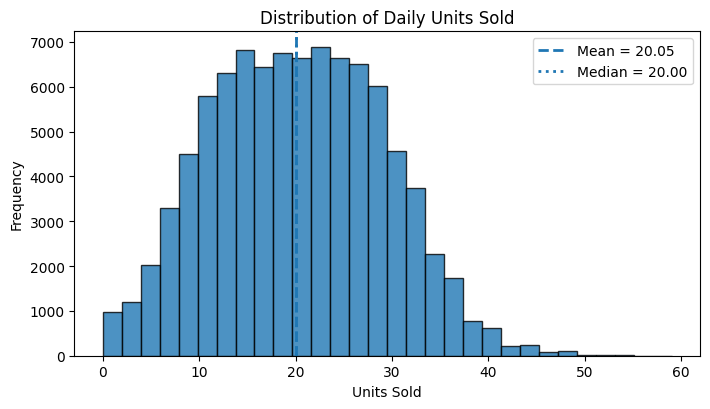

In [5]:
# Figure 1 — Distribution of demand
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.hist(df["Units_Sold"], bins=30, edgecolor="black", alpha=0.8)
ax.axvline(df["Units_Sold"].mean(), linestyle="--", linewidth=2, label=f"Mean = {df['Units_Sold'].mean():.2f}")
ax.axvline(df["Units_Sold"].median(), linestyle=":", linewidth=2, label=f"Median = {df['Units_Sold'].median():.2f}")
ax.set_title("Distribution of Daily Units Sold")
ax.set_xlabel("Units Sold")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

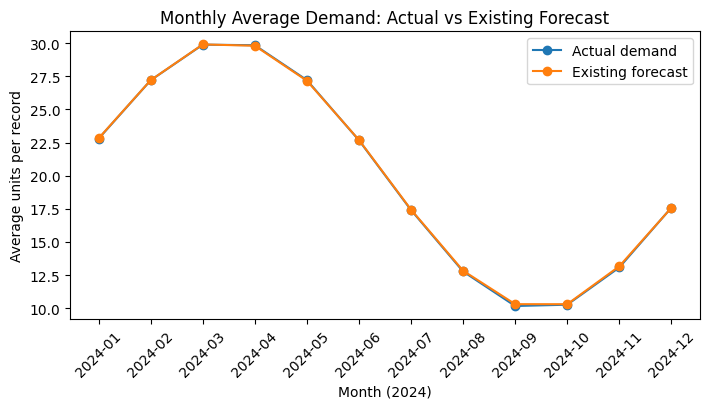

,Avg_Demand,Avg_Forecast,Avg_Inventory,Avg_Reorder,Promo_Rate,Below_Reorder
MonthLabel,,,,,,
2024-01,22.797548,22.822270,527.469935,300.068,0.105032,0.039871
2024-02,27.198345,27.205903,459.948000,300.068,0.094621,0.075172
2024-03,29.883355,29.900533,459.068387,300.068,0.104516,0.080516
2024-04,29.839067,29.799709,454.417600,300.068,0.102667,0.082800
2024-05,27.205290,27.158453,459.081161,300.068,0.102968,0.074710
2024-06,22.668400,22.691484,460.489733,300.068,0.096533,0.063867
2024-07,17.408387,17.441512,466.504129,300.068,0.107742,0.047097
2024-08,12.776645,12.833328,477.487871,300.068,0.101032,0.032258
2024-09,10.173867,10.312007,472.321067,300.068,0.098800,0.026133


In [6]:
# Figure 2 — Monthly demand versus existing forecast
monthly = df.assign(MonthLabel=df["Date"].dt.to_period("M").astype(str)).groupby("MonthLabel").agg(
    Avg_Demand=("Units_Sold", "mean"),
    Avg_Forecast=("Demand_Forecast", "mean"),
    Avg_Inventory=("Inventory_Level", "mean"),
    Avg_Reorder=("Reorder_Point", "mean"),
    Promo_Rate=("Promotion_Flag", "mean"),
    Below_Reorder=("Below_Reorder_Point", "mean")
)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
x = np.arange(len(monthly))
ax.plot(x, monthly["Avg_Demand"], marker="o", label="Actual demand")
ax.plot(x, monthly["Avg_Forecast"], marker="o", label="Existing forecast")
ax.set_xticks(x)
ax.set_xticklabels(monthly.index, rotation=45)
ax.set_title("Monthly Average Demand: Actual vs Existing Forecast")
ax.set_xlabel("Month (2024)")
ax.set_ylabel("Average units per record")
ax.legend()
plt.tight_layout()
plt.show()

display(monthly)

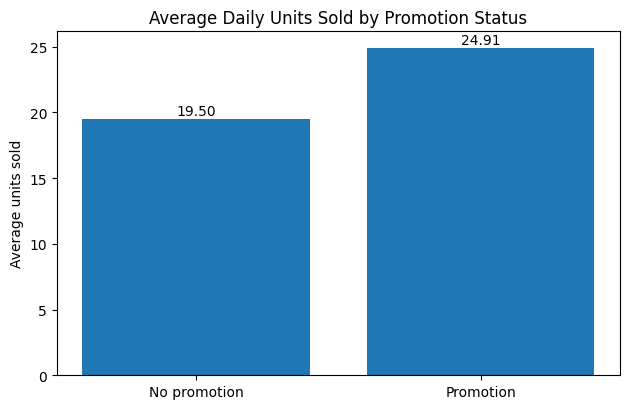

Descriptive promotion lift: 27.74%


In [7]:
# Figure 3 — Promotion comparison
promo = df.groupby("Promotion_Flag")["Units_Sold"].mean()
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.bar(["No promotion", "Promotion"], [promo.loc[0], promo.loc[1]])
ax.set_title("Average Daily Units Sold by Promotion Status")
ax.set_ylabel("Average units sold")
for i, value in enumerate([promo.loc[0], promo.loc[1]]):
    ax.text(i, value + 0.3, f"{value:.2f}", ha="center")
plt.tight_layout()
plt.show()

promo_lift = (promo.loc[1] / promo.loc[0] - 1) * 100
print(f"Descriptive promotion lift: {promo_lift:.2f}%")

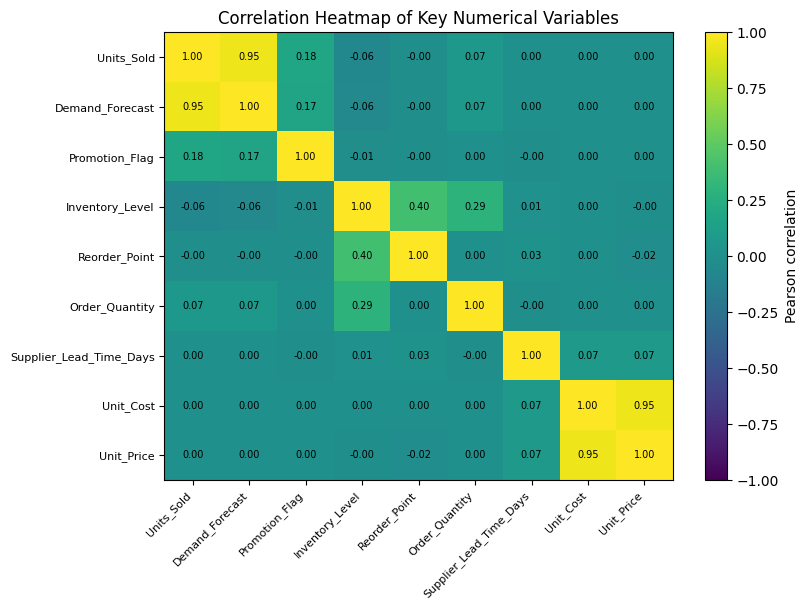

In [8]:
# Figure 4 — Correlation heatmap
corr_cols = [
    "Units_Sold", "Demand_Forecast", "Promotion_Flag", "Inventory_Level",
    "Reorder_Point", "Order_Quantity", "Supplier_Lead_Time_Days",
    "Unit_Cost", "Unit_Price"
]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8.2, 6.2))
im = ax.imshow(corr, vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols, fontsize=8)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Correlation Heatmap of Key Numerical Variables")
fig.colorbar(im, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

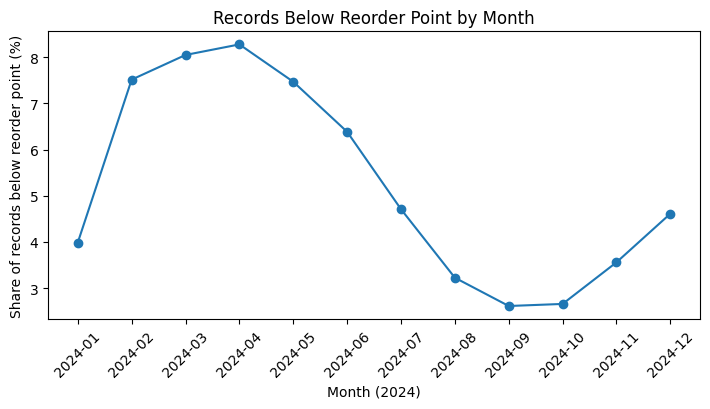

Overall below-reorder rate: 5.25%
Stockout records in source: 0


In [9]:
# Figure 5 — inventory records below reorder point
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(np.arange(len(monthly)), monthly["Below_Reorder"] * 100, marker="o")
ax.set_xticks(np.arange(len(monthly)))
ax.set_xticklabels(monthly.index, rotation=45)
ax.set_title("Records Below Reorder Point by Month")
ax.set_xlabel("Month (2024)")
ax.set_ylabel("Share of records below reorder point (%)")
plt.tight_layout()
plt.show()

print(f"Overall below-reorder rate: {df['Below_Reorder_Point'].mean()*100:.2f}%")
print(f"Stockout records in source: {int(df['Stockout_Flag'].sum())}")

## 6. Statistical Analysis

In [10]:
stats_vars = ["Units_Sold", "Demand_Forecast", "Inventory_Level", "Reorder_Point", "Order_Quantity", "Unit_Price"]
rows = []
for col in stats_vars:
    s = df[col]
    rows.append([
        col, s.mean(), s.median(), s.mode().iloc[0], s.std(), s.var(),
        s.quantile(0.75) - s.quantile(0.25)
    ])

stat_table = pd.DataFrame(
    rows,
    columns=["Variable", "Mean", "Median", "Mode", "Std Dev", "Variance", "IQR"]
)
display(stat_table.round(3))

print("Demand vs forecast correlation:", round(df["Units_Sold"].corr(df["Demand_Forecast"]), 4))
print("Mean forecast bias (forecast - actual):", round((df["Demand_Forecast"] - df["Units_Sold"]).mean(), 4))

,Variable,Mean,Median,Mode,Std Dev,Variance,IQR
0,Units_Sold,20.055,20.00,20.00,9.069,82.240,14.00
1,Demand_Forecast,20.082,19.95,0.00,9.504,90.325,13.98
2,Inventory_Level,471.522,461.00,369.00,133.488,17819.047,194.00
3,Reorder_Point,300.068,300.00,218.00,54.880,3011.808,94.00
4,Order_Quantity,19.272,0.00,0.00,82.341,6780.012,0.00
5,Unit_Price,18.262,18.18,23.34,7.121,50.711,11.39


Demand vs forecast correlation: 0.9493
Mean forecast bias (forecast - actual): 0.0275


## 7. Model Development

In [11]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred)
    }

benchmark_pred = test["Demand_Forecast"].values
lag1_pred = test["Lag_1"].values
lag7_pred = test["Lag_7"].values

linear = LinearRegression()
linear.fit(train[features], train[target])
linear_pred = linear.predict(test[features])

model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)
model.fit(train[features], train[target])
model_pred = model.predict(test[features])

comparison = pd.DataFrame([
    ["Existing Demand Forecast", *regression_metrics(test[target], benchmark_pred).values()],
    ["Naive Lag-1", *regression_metrics(test[target], lag1_pred).values()],
    ["Naive Lag-7", *regression_metrics(test[target], lag7_pred).values()],
    ["Linear Regression", *regression_metrics(test[target], linear_pred).values()],
    ["HistGradientBoosting (Final)", *regression_metrics(test[target], model_pred).values()],
], columns=["Model", "MAE", "MSE", "RMSE", "R2"])

display(comparison.round(4))

,Model,MAE,MSE,RMSE,R2
0,Existing Demand Forecast,2.3725,8.8725,2.9787,0.7528
1,Naive Lag-1,5.9188,55.8635,7.4742,-0.5563
2,Naive Lag-7,5.9466,55.9217,7.4781,-0.5579
3,Linear Regression,2.0704,6.7413,2.5964,0.8122
4,HistGradientBoosting (Final),2.1833,7.5145,2.7413,0.7907


### Model choice

Linear Regression is used as an interpretable baseline. The final model is HistGradientBoostingRegressor because the demand relationship can be nonlinear and may depend on interactions between the existing forecast, promotion, rolling demand and seasonal variables. A time-based split is used instead of random shuffling so that future dates are not used to predict earlier dates.

In [12]:
train_pred = model.predict(train[features])
train_metrics = regression_metrics(train[target], train_pred)
test_metrics = regression_metrics(test[target], model_pred)

print("Training metrics:", {k: round(v, 4) for k, v in train_metrics.items()})
print("Testing metrics :", {k: round(v, 4) for k, v in test_metrics.items()})

Training metrics: {'MAE': 2.0324, 'MSE': 6.5017, 'RMSE': 2.5498, 'R2': 0.9285}
Testing metrics : {'MAE': 2.1833, 'MSE': 7.5145, 'RMSE': 2.7413, 'R2': 0.7907}


,Feature,Importance
17,Demand_Forecast,3.926800
6,Promotion_Flag,0.032692
21,DayOfYear_Sin,0.022304
10,Rolling_Mean_30,0.018976
19,Month_Sin,0.001133
7,Lag_1,0.000814
5,Unit_Price,0.000715
4,Unit_Cost,0.000540
9,Rolling_Mean_7,0.000449
1,Supplier_Lead_Time_Days,0.000057


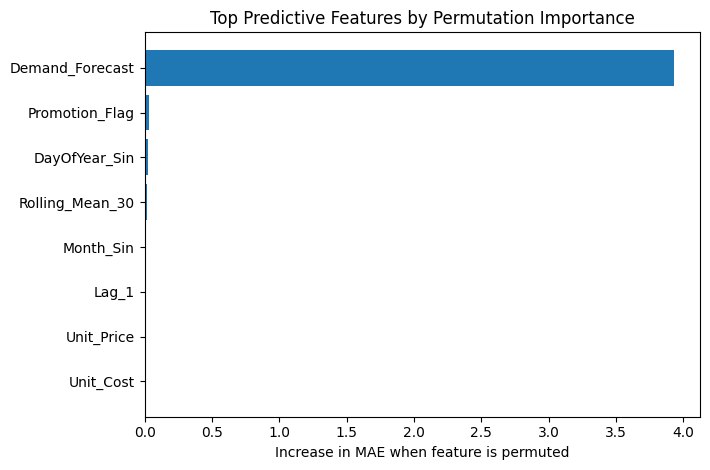

In [13]:
perm = permutation_importance(
    model, test[features], test[target],
    n_repeats=2, random_state=42,
    scoring="neg_mean_absolute_error", n_jobs=1
)

importance = pd.DataFrame({
    "Feature": features,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

display(importance.head(12).round(6))

top = importance.head(8).sort_values("Importance")
fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.barh(top["Feature"], top["Importance"])
ax.set_title("Top Predictive Features by Permutation Importance")
ax.set_xlabel("Increase in MAE when feature is permuted")
plt.tight_layout()
plt.show()

## 8. Model Evaluation and Diagnostics

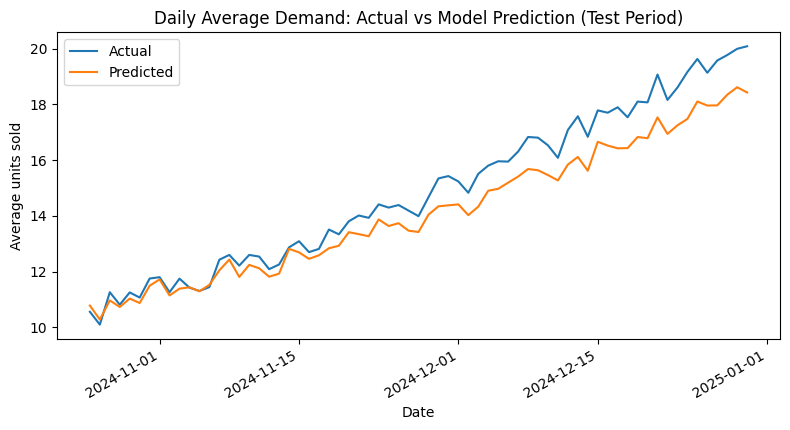

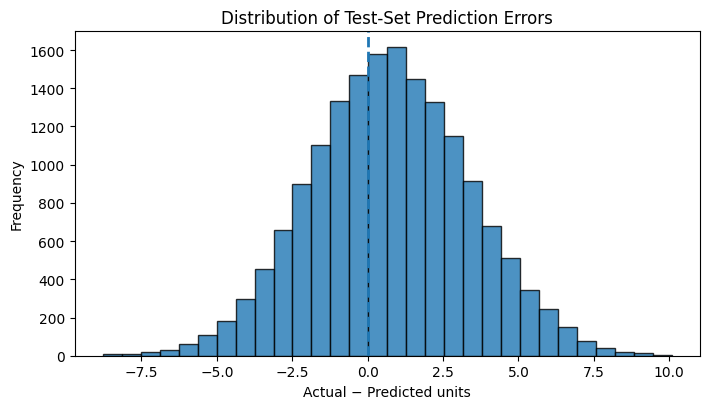

In [14]:
pred_results = test[
    ["Date", "SKU_ID", "Warehouse_ID", "Supplier_ID", "Region",
     "Units_Sold", "Demand_Forecast", "Promotion_Flag",
     "Inventory_Level", "Reorder_Point"]
].copy()
pred_results["Predicted_Demand"] = model_pred
pred_results["Absolute_Error"] = np.abs(
    pred_results["Units_Sold"] - pred_results["Predicted_Demand"]
)

daily_test = pred_results.groupby("Date").agg(
    Actual=("Units_Sold", "mean"),
    Predicted=("Predicted_Demand", "mean")
).reset_index()

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(daily_test["Date"], daily_test["Actual"], label="Actual")
ax.plot(daily_test["Date"], daily_test["Predicted"], label="Predicted")
ax.set_title("Daily Average Demand: Actual vs Model Prediction (Test Period)")
ax.set_xlabel("Date")
ax.set_ylabel("Average units sold")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

residuals = test[target].values - model_pred
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.hist(residuals, bins=30, edgecolor="black", alpha=0.8)
ax.axvline(0, linestyle="--", linewidth=2)
ax.set_title("Distribution of Test-Set Prediction Errors")
ax.set_xlabel("Actual − Predicted units")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [15]:
existing = regression_metrics(test[target], benchmark_pred)
final = regression_metrics(test[target], model_pred)

mae_improvement = (existing["MAE"] - final["MAE"]) / existing["MAE"] * 100
rmse_improvement = (existing["RMSE"] - final["RMSE"]) / existing["RMSE"] * 100

print(f"MAE improvement over existing forecast: {mae_improvement:.2f}%")
print(f"RMSE improvement over existing forecast: {rmse_improvement:.2f}%")
print(f"Forecast-to-demand correlation: {df['Demand_Forecast'].corr(df['Units_Sold']):.4f}")

MAE improvement over existing forecast: 7.97%
RMSE improvement over existing forecast: 7.97%
Forecast-to-demand correlation: 0.9493


## 9. Export Supporting Files

In [16]:
os.makedirs("outputs", exist_ok=True)

df.to_csv("outputs/supply_chain_cleaned_dataset.csv", index=False)
model_df.to_csv("outputs/supply_chain_model_dataset.csv", index=False)
pred_results.to_csv("outputs/test_predictions.csv", index=False)

print("Saved supporting CSV files to ./outputs/")

Saved supporting CSV files to ./outputs/
